In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Titanic Survival Prediction

This project focuses on building machine learning models to predict whether a passenger survived the Titanic disaster. The task is formulated as a **binary classification problem**, where the model predicts whether a passenger survived (1) or did not survive (0) based on available information.

The first stage of the project focuses on **data preprocessing and exploratory analysis**.
The dataset contains missing values and several categorical variables stored as strings, therefore multiple preprocessing steps were required. These include handling missing values and transforming categorical features into numerical representations using techniques such as **one-hot encoding** and **binary encoding**, so that the data can be used by machine learning models.

After cleaning the dataset, a **baseline model (Dummy Classifier)** was created to establish a simple reference point for model performance. This allows comparison with more advanced models and ensures that the trained models perform better than naive predictions.

Next, several machine learning models were trained and evaluated to analyze their performance on this task. The experiments include tuning selected hyperparameters and observing how they affect classification metrics. Model performance is evaluated using appropriate metrics for classification problems, and the results are analyzed to better understand the strengths and limitations of different approaches.

The goal of this project is not only to build predictive models, but also to demonstrate the full **machine learning workflow**, including data cleaning, feature preparation, model training, evaluation, and interpretation of results.

# Part I. Data Analysis and Preprocessing

My aim is to analyze and process the dataset so that it can later be used to train a model to classify each passenger as survivor (1) or non-survivor (0).

In [2]:
titanic_df = pd.read_csv('data/titanic.csv', index_col='PassengerId')
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Type conversion

In [3]:
print(titanic_df.dtypes)
titanic_df = titanic_df.convert_dtypes()
print(titanic_df.dtypes)

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object
Survived             Int64
Pclass               Int64
Name        string[python]
Sex         string[python]
Age                Float64
SibSp                Int64
Parch                Int64
Ticket      string[python]
Fare               Float64
Cabin       string[python]
Embarked    string[python]
dtype: object


# Cleaning Naan values
At first, I checked what is the percentage of missing values in each column. My conclusions were as follows:
- in Cabin column there is too much Naan values, and it shouldn't be important in classifying, can be deleted
- Embarked, Fare and Age columns will be investigated to fill them with appropriate values

It's unfortunate that there are so many Naans in Cabin column, as each record also contains information about the deck. There were 10 decks in Titanic, each located on different level, and this could be useful for predictions. For example, passengers on lower decks may have had a longer path to reach the upper levels, potentially reducing their chances of survival.

In [4]:
def get_percentage_of_naan(dataset, axis):
    missing_vals = dataset.isna().sum(axis=axis)
    return np.round(missing_vals / dataset.shape[axis] * 100, 2)

In [5]:
print(get_percentage_of_naan(titanic_df, 0))

Survived     0.00
Pclass       0.00
Name         0.00
Sex          0.00
Age         19.87
SibSp        0.00
Parch        0.00
Ticket       0.00
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64


### Dropping the column Cabin

In [6]:
titanic_df.drop(columns='Cabin', inplace=True)

### Filling Naans in the Embarked column
Embarked is a categorical type column. I will replace Naans with the most frequent value "S"

In [7]:
titanic_df.groupby("Embarked").size()

Embarked
C    168
Q     77
S    644
dtype: int64

In [8]:
mask = titanic_df['Embarked'].isna()
titanic_df.loc[mask, 'Embarked'] = 'S'

### Filling Naans in the Age column
The distribution is right-skewed as seen on the plot. mode < median < mean. Median is more robust to outliers on the right side, so it better reflects the tendency of the data. Therefore, I will fill Naan values with median

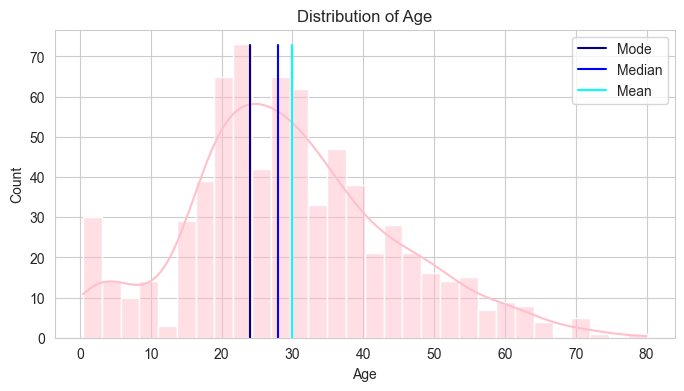

In [9]:
def draw_distribution(dataset, column):
    median = np.round(dataset[column].median())
    mean = np.round(dataset[column].mean())
    mode = np.round(dataset[column].mode()[0])

    plt.figure(figsize=(8, 4))
    sns.histplot(dataset[column], kde=True, bins=30, color='pink')

    plt.axvline(mode, 0, 0.95, color='darkblue', label='Mode')
    plt.axvline(median, 0, 0.95, color='blue', label='Median')
    plt.axvline(mean, 0, 0.95, color='cyan', label='Mean')

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

draw_distribution(titanic_df, 'Age')

In [10]:
mediana = titanic_df['Age'].median()
titanic_df['Age'] = titanic_df['Age'].fillna(mediana)

### Filling Naans in the Fare column
Column Fare is highly right-skewed and contains extreme outliers (some very expensive tickets) that extremely affect the mean. Therefore, I will fill Naa values with the median.

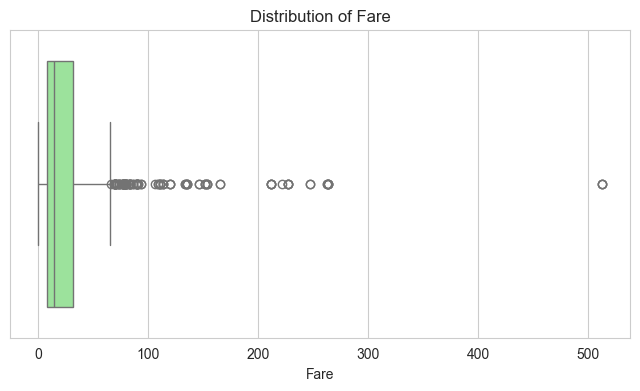

In [11]:
def boxplot(dataset, column):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataset[column].dropna(), color='lightgreen')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.show()

boxplot(titanic_df, 'Fare')

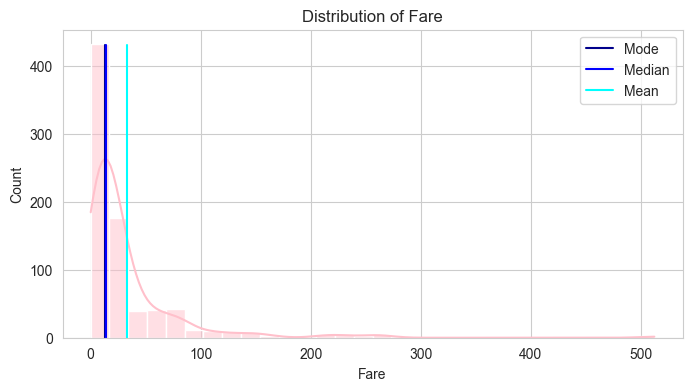

In [12]:
draw_distribution(titanic_df, 'Fare')
mediana = titanic_df['Fare'].median()
titanic_df['Fare'] = titanic_df['Fare'].fillna(mediana)

# Feature Engineering
### FamilySize Column = SibSp + Parch + 1
The FamilySize feature represents how many family members are travelling with the passenger. It can be associated with survival, passengers travelling alone could have lower chances of survival. Conversely, very big families could also have reduced survival chance, as they may have problems with coordinating.

In [13]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

### IsAlone Column
As stated previously, alone passengers may have decreased survival.

In [14]:
titanic_df['IsAlone'] = titanic_df['FamilySize'] == 1
titanic_df['IsAlone'] = titanic_df['IsAlone'].astype(int)

# Categorical data encoding
Columns Name and Ticket don't bring much information correlated to survival. Therefore, they can be deleted to not distract the model.
### Usunięcie kolumn Name i Ticket

In [15]:
titanic_df.drop(columns='Name', inplace=True)
titanic_df.drop(columns='Ticket', inplace=True)

### Binary Encoding of the Sex Column

In [16]:
titanic_df['Sex'] = titanic_df['Sex'].map({
    'female': 1, 'male': 0
})

### One hot encoding of the Embarked Column
It contains one of three values: 'C', 'Q' and 'S'. Since there is no order between categories, they shouldn't be encoded with integers, as it could confuse the model. Therefore, I will use one hot encoding.

In [17]:
titanic_df = pd.get_dummies(data=titanic_df, prefix='Embarked', columns=['Embarked'], dtype=np.int64)

# Data visualisation
At first, I want to show Age and Fare relationship. As we can see, the outliers (very high Fare values) occur only at about 35 years old.

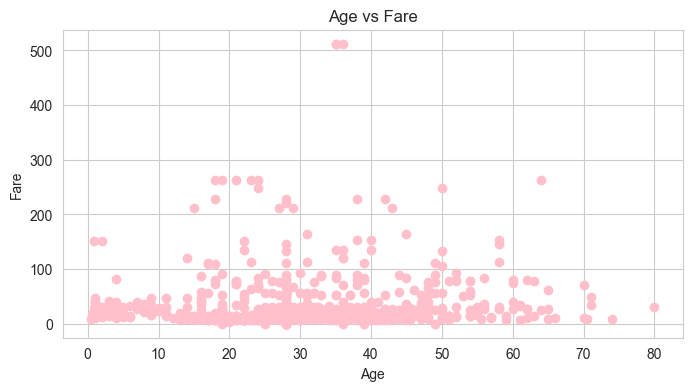

In [18]:
plt.figure(figsize=(8,4))
plt.scatter(titanic_df['Age'], titanic_df['Fare'], color='pink')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.show()

I want to show how many people survived or did not survive depending on gender. As shown below, significantly more women survived than did not, unlike men. This suggests that being a woman significantly increased the chances of survival.

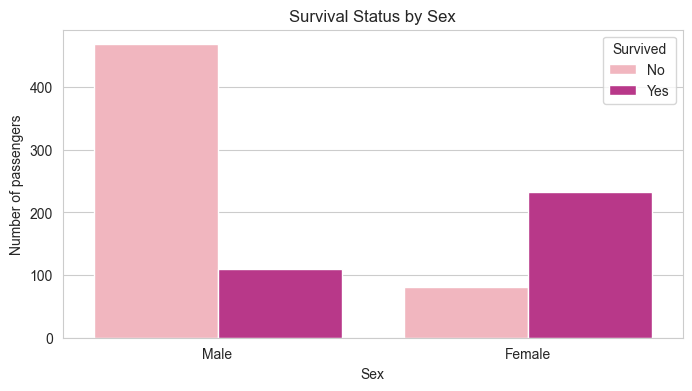

There was 4.0 times more non-survivors than survivors among men.


In [19]:
titanic_mapped = titanic_df
titanic_mapped['Survived'] = titanic_mapped['Survived'].map({
    0:"No",
    1:"Yes"
})
df_grouped = titanic_mapped.groupby(['Survived', 'Sex']).size().reset_index(name='Count')
plt.figure(figsize=(8,4))
sns.barplot(df_grouped, x='Sex', y='Count', hue='Survived', palette='RdPu')
plt.ylabel('Number of passengers')
plt.xticks(ticks=[0,1],labels=['Male', 'Female'])
plt.title('Survival Status by Sex')
plt.show()

# Counting male survived vs not survived
male = df_grouped.loc[df_grouped['Sex'] == 0]
ratio = male.loc[0, 'Count']  / male.loc[2, 'Count']
print(f"There was {np.round(ratio)} times more non-survivors than survivors among men.")

Another correlation between data can be correlation between Class and Survival. The higher class, the wealthier the person. The plot shows, that people in 1st class had the highest survival ratio, and people in 3rd class the lowest.

Text(0.5, 1.0, 'Survival Status by Class')

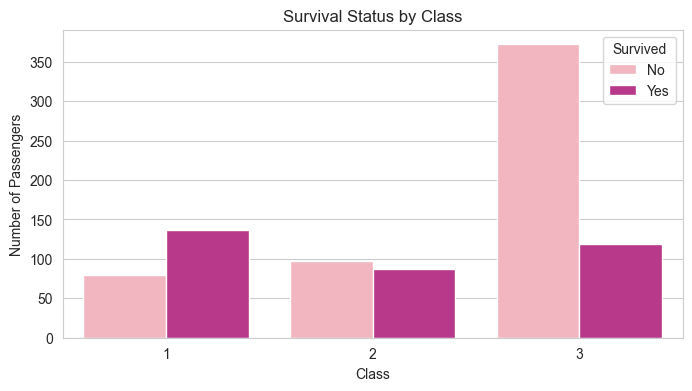

In [20]:
df_grouped = titanic_mapped.groupby(['Pclass', 'Survived']).size().reset_index(name='Count')
plt.figure(figsize=(8,4))
sns.barplot(df_grouped, x='Pclass', y='Count', hue='Survived', palette='RdPu')
plt.xlabel('Class')
plt.ylabel('Number of Passengers')
plt.title('Survival Status by Class')

The violin plot shows that children had a higher chance of survival, while elderly passengers had lower chances. The plot on the right is slightly thinner at the top and wider at the bottom compared to the plot on the left.

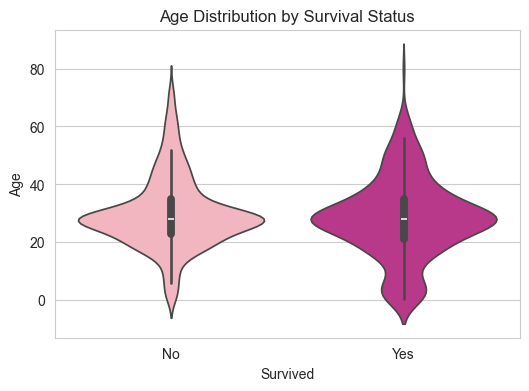

In [21]:
plt.figure(figsize=(6,4))
sns.violinplot(data=titanic_mapped, x='Survived', y='Age',palette='RdPu',hue='Survived', legend=False)
plt.title('Age Distribution by Survival Status')
plt.show()

In [22]:
titanic_df.to_csv('data/titanic_cleaned.csv', index='PassengerId')

# Part II. Titanic Passengers Classification
## Data Standardization
Most of the columns have small number values, except for columns Age and Fare. They need to be normalized, so the model doesn't favor them. Column Fare is strongly right-skewed and has some values very much greater than others, so I will apply log transformation to reduce skewness and limit influence of the outliers.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

In [24]:
titanic_df['Fare'] = np.log1p(titanic_df['Fare'])

y = titanic_df['Survived']
X = titanic_df.drop(['Survived'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True, random_state=8)
scaler = StandardScaler()
X_train[['Fare', 'Age']] = scaler.fit_transform(X_train[['Fare', 'Age']])
X_test[['Fare', 'Age']] = scaler.transform(X_test[['Fare', 'Age']])
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
769,3,0,-0.147239,1,0,0.269444,2,0,0,1,0
388,2,1,0.462262,0,0,-0.344032,1,1,0,0,1
824,3,1,-0.223427,0,1,-0.384059,2,0,0,0,1
779,3,0,-0.147239,0,0,-0.837738,1,1,0,1,0
158,3,0,0.005136,0,0,-0.800937,1,1,0,0,1


# Dataset balance
Before creating ML models, it is useful to check how imbalanced the dataset is. Titanic dataset after preprocessing is slightly imbalanced: 38.38% of survivors and 61.62% of non-survivors.

In [25]:
grouped = titanic_df.groupby('Survived').size()
total = titanic_df.shape[0]
percent_dead = grouped.iloc[0]/total * 100
percent_alive = 100 - percent_dead
print("Percent of survivors: ", round(percent_alive,2), "%")
print("Percent of non-survivors: ", round(percent_dead,2), "%")

Percent of survivors:  38.38 %
Percent of non-survivors:  61.62 %


# Creating baseline dummy
Creating a baseline model using a DummyClassifier with the stratified strategy. Since the dataset is slightly imbalanced, this approach preserves the class distribution in predictions, providing a more realistic baseline to compare against.

              precision    recall  f1-score   support

          No       0.61      0.66      0.63       108
         Yes       0.41      0.37      0.39        71

    accuracy                           0.54       179
   macro avg       0.51      0.51      0.51       179
weighted avg       0.53      0.54      0.54       179



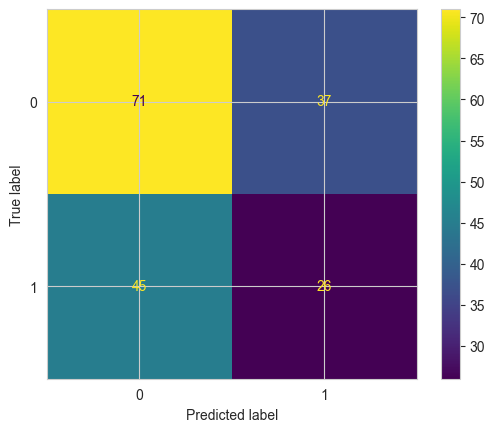

In [26]:
def show_confusion_matrix(cm):
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot()
    plt.show()

model = DummyClassifier(strategy = 'stratified')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
matrix = confusion_matrix(y_test, y_pred)
show_confusion_matrix(matrix)

# SVM
First ML model I will use is SVM. It is used mainly for classification. It finds the best hyperplane that separates different classes. The default hyperparameters are: C=1.0, kernel='rbf', gamma='scale' and class_weight=None

In [27]:
from sklearn.svm import SVC

clf = SVC()
clf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Inferring on test data
The model performs quite well on the test data, achieving an accuracy of around 0.78. However, its performance is lower for class 1, likely due to the smaller number of samples representing this class in the dataset.

              precision    recall  f1-score   support

          No       0.80      0.85      0.83       108
         Yes       0.75      0.68      0.71        71

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



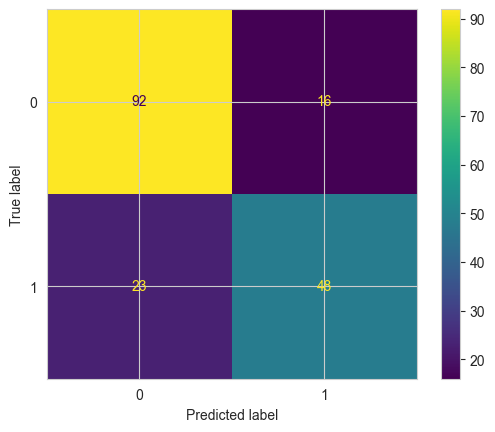

In [28]:
y_pred_clf = clf.predict(X_test)
print(classification_report(y_test, y_pred_clf))
show_confusion_matrix(confusion_matrix(y_test, y_pred_clf))

### Inferring on train data
The model performs slightly better on the training data, achieving an accuracy of 0.83 compared to 0.78 on the test set. This small difference suggests that there is no significant overfitting and that the model generalizes reasonably well.

              precision    recall  f1-score   support

          No       0.84      0.91      0.87       441
         Yes       0.83      0.72      0.77       271

    accuracy                           0.84       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.83      0.84      0.83       712



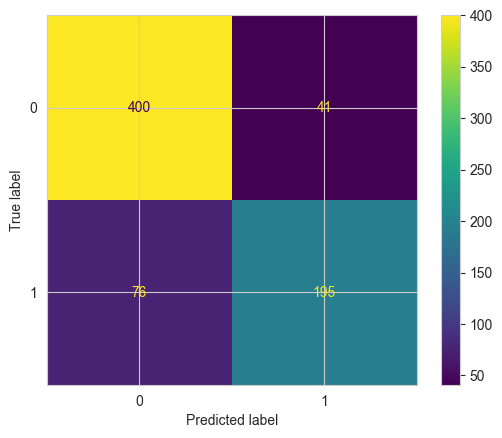

In [29]:
y_pred_on_train = clf.predict(X_train)
print(classification_report(y_train, y_pred_on_train))
show_confusion_matrix(confusion_matrix(y_train, y_pred_on_train))

### Hyperparameter tuning
I decided to tune the model by optimizing the hyperparameters C, gamma, and class_weight. The best performing configuration  was found to be: C=1, gamma=0.1, class_weight=None.

In [30]:
param_grid = {
    'C' : [0.1,1,10,100,1000],
    'gamma' : [1, 0.1, 0.01, 0.001, 0.0001],
    'class_weight' : [None, 'balanced']
}
grid = GridSearchCV(SVC(), param_grid=param_grid, verbose=3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END .C=0.1, class_weight=None, gamma=1;, score=0.622 total time=   0.0s
[CV 2/5] END .C=0.1, class_weight=None, gamma=1;, score=0.636 total time=   0.0s
[CV 3/5] END .C=0.1, class_weight=None, gamma=1;, score=0.620 total time=   0.0s
[CV 4/5] END .C=0.1, class_weight=None, gamma=1;, score=0.641 total time=   0.0s
[CV 5/5] END .C=0.1, class_weight=None, gamma=1;, score=0.620 total time=   0.0s
[CV 1/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.790 total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.776 total time=   0.0s
[CV 3/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.810 total time=   0.0s
[CV 4/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.775 total time=   0.0s
[CV 5/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.789 total time=   0.0s
[CV 1/5] END C=0.1, class_weight=None, gamma=0.01;, score=0.622 total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, g

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'gamma': [1, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


### Creating a model with best estimator
The results obtained with the default SVC and the tuned model are identical or extremely similar, indicating that hyperparameter tuning did not improve performance.

              precision    recall  f1-score   support

          No       0.80      0.85      0.83       108
         Yes       0.75      0.68      0.71        71

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



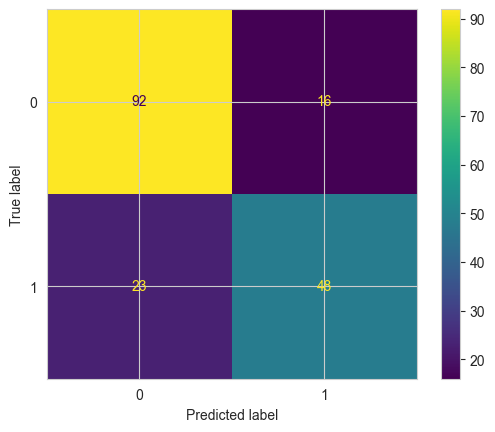

In [31]:
# creating model with best hyperparameters
clf_tuned = grid.best_estimator_
clf_tuned.fit(X_train, y_train)
y_pred_tuned = clf_tuned.predict(X_test)
print(classification_report(y_test, y_pred_tuned))
show_confusion_matrix(confusion_matrix(y_test, y_pred_tuned))

### Summary of SVC
The SVC model outperforms the Dummy Classifier; however, the accuracy remains below 80%. Hyperparameter tuning resulted in no improvements.
# Decision Tree
It's trained using default parameters, without restricting the maximum depth of the tree. While this allows the model to fully adapt to the training data, it may lead to overfitting, as the tree can become overly complex and capture noise rather than general patterns.

In [32]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Inferring on train data

              precision    recall  f1-score   support

          No       0.79      0.79      0.79       108
         Yes       0.68      0.68      0.68        71

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179



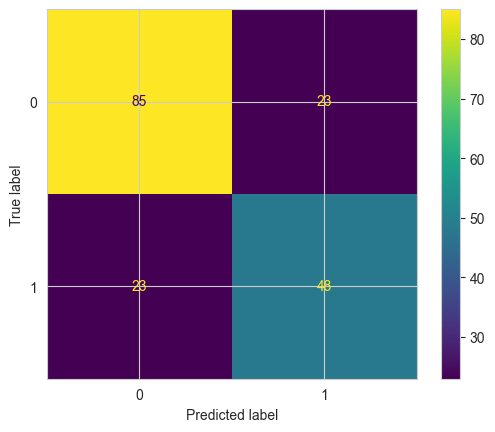

[Text(0.525697741828622, 0.9736842105263158, 'Sex <= 0.5\ngini = 0.471\nsamples = 712\nvalue = [441, 271]'),
 Text(0.22984071333922262, 0.9210526315789473, 'Pclass <= 1.5\ngini = 0.29\nsamples = 460\nvalue = [379, 81]'),
 Text(0.3777692275839223, 0.9473684210526316, 'True  '),
 Text(0.06713780918727916, 0.868421052631579, 'Age <= 1.757\ngini = 0.463\nsamples = 99\nvalue = [63, 36]'),
 Text(0.04240282685512368, 0.8157894736842105, 'Fare <= 0.348\ngini = 0.491\nsamples = 81\nvalue = [46, 35]'),
 Text(0.014134275618374558, 0.7631578947368421, 'Age <= -0.947\ngini = 0.332\nsamples = 19\nvalue = [15, 4]'),
 Text(0.007067137809187279, 0.7105263157894737, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.02120141342756184, 0.7105263157894737, 'Age <= 0.272\ngini = 0.278\nsamples = 18\nvalue = [15, 3]'),
 Text(0.014134275618374558, 0.6578947368421053, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.028268551236749116, 0.6578947368421053, 'Age <= 0.386\ngini = 0.397\nsamples = 11\nvalue =

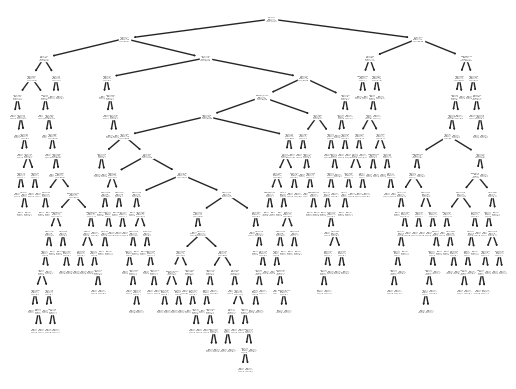

In [33]:
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))
show_confusion_matrix(confusion_matrix(y_test, y_pred))
from sklearn import tree
tree.plot_tree(model,feature_names=list(X_test.columns))

### Inferring on test data
As expected, there is overfitting ocurring. Inferring on test data showed 0.76 accuracy, while inferring on train data is 0.98. I will assign max_depth=3

              precision    recall  f1-score   support

          No       0.85      0.92      0.88       441
         Yes       0.84      0.73      0.78       271

    accuracy                           0.85       712
   macro avg       0.84      0.82      0.83       712
weighted avg       0.85      0.85      0.84       712



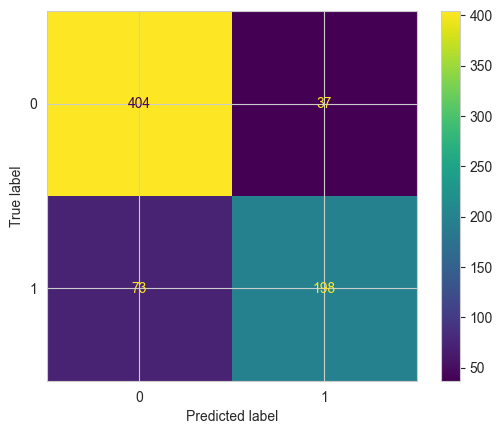

[Text(0.5, 0.9, 'Sex <= 0.5\ngini = 0.471\nsamples = 712\nvalue = [441, 271]'),
 Text(0.25, 0.7, 'Pclass <= 1.5\ngini = 0.29\nsamples = 460\nvalue = [379, 81]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Age <= 1.757\ngini = 0.463\nsamples = 99\nvalue = [63, 36]'),
 Text(0.0625, 0.3, 'Fare <= 0.348\ngini = 0.491\nsamples = 81\nvalue = [46, 35]'),
 Text(0.03125, 0.1, 'gini = 0.332\nsamples = 19\nvalue = [15, 4]'),
 Text(0.09375, 0.1, 'gini = 0.5\nsamples = 62\nvalue = [31, 31]'),
 Text(0.1875, 0.3, 'Age <= 3.472\ngini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.15625, 0.1, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.21875, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'Age <= -1.785\ngini = 0.218\nsamples = 361\nvalue = [316, 45]'),
 Text(0.3125, 0.3, 'FamilySize <= 4.5\ngini = 0.48\nsamples = 15\nvalue = [6, 9]'),
 Text(0.28125, 0.1, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.34375, 0.1, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 

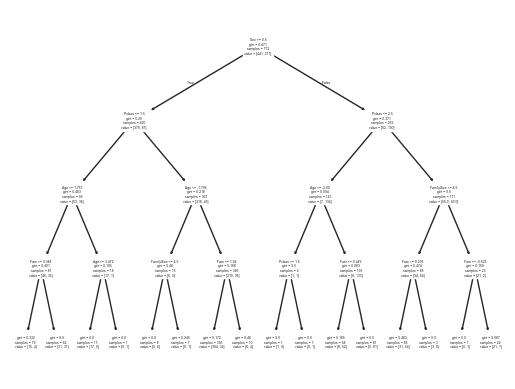

In [38]:
y_pred = model.predict(X_train)
print(classification_report(y_train,y_pred))
show_confusion_matrix(confusion_matrix(y_train, y_pred))
tree.plot_tree(model,feature_names=list(X_test.columns))

### Changing max_depth=3

              precision    recall  f1-score   support

          No       0.79      0.83      0.81       108
         Yes       0.72      0.66      0.69        71

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



[Text(0.5, 0.875, 'x[1] <= 0.5\ngini = 0.471\nsamples = 712\nvalue = [441, 271]'),
 Text(0.25, 0.625, 'x[0] <= 1.5\ngini = 0.29\nsamples = 460\nvalue = [379, 81]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[2] <= 1.757\ngini = 0.463\nsamples = 99\nvalue = [63, 36]'),
 Text(0.0625, 0.125, 'gini = 0.491\nsamples = 81\nvalue = [46, 35]'),
 Text(0.1875, 0.125, 'gini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.375, 0.375, 'x[2] <= -1.785\ngini = 0.218\nsamples = 361\nvalue = [316, 45]'),
 Text(0.3125, 0.125, 'gini = 0.48\nsamples = 15\nvalue = [6, 9]'),
 Text(0.4375, 0.125, 'gini = 0.186\nsamples = 346\nvalue = [310, 36]'),
 Text(0.75, 0.625, 'x[0] <= 2.5\ngini = 0.371\nsamples = 252\nvalue = [62, 190]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[2] <= -2.09\ngini = 0.094\nsamples = 141\nvalue = [7, 134]'),
 Text(0.5625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6875, 0.125, 'gini = 0.083\nsamples = 139\nvalue = [6, 133]'),
 Text(0.875, 0.375, '

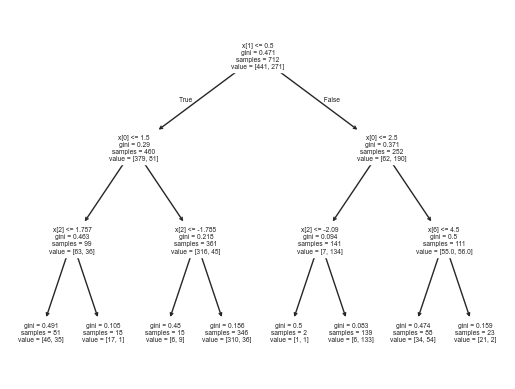

In [35]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
tree.plot_tree(model)

In [36]:
y_pred = model.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

          No       0.84      0.90      0.87       441
         Yes       0.81      0.72      0.76       271

    accuracy                           0.83       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.83      0.83      0.83       712



### Hyperparameter tuning
With max_depth=3 I got rid of overfitting, but the overall performance is still better with train data (it is to be expected).
The performance can be improved with hyperparameter tuning.

In [37]:
param_grid = {
    'max_depth' : range(1,10),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion' : ['gini', 'entropy', 'log_loss'],
}
grid = GridSearchCV(DecisionTreeClassifier(), param_grid=param_grid, verbose=3)
grid.fit(X_train, y_train)
model = grid.best_estimator_
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
[CV 1/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.839 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.741 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.838 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.782 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.796 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.839 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.741 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.838 total time=   0.0s
[CV 4/5] END c